# 01. Pharmacovigilance Exploratory Data Analysis (EDA)
**Project**: PharmaGuard ADR Severity Prediction  
**Objective**: Analyze patient demographics, drug class distributions, adverse event severity, and calculate epidemiological disproportionality metrics (Reporting Odds Ratio & Proportional Reporting Ratio).


In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Environment successfully initialized.")


Environment successfully initialized.


## 1. Data Ingestion & Initial Inspection


In [2]:
# Load raw adverse event reports
raw_data_path = os.path.join("..", "data", "raw", "pharma_adverse_events.csv")
df = pd.read_csv(raw_data_path)

print(f"Dataset Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
df.head(10)


Dataset Dimensions: 1,000 rows x 16 columns



,report_id,report_date,patient_age,patient_sex,patient_weight_kg,drug_class,route_of_administration,daily_dose_mg,treatment_duration_days,concomitant_drug_count,interaction_risk_index,renal_impairment_flag,hepatic_impairment_flag,reporting_source,time_to_onset_days,serious_adverse_event
0,FDA-AER-1000001,2024-03-01,42,Male,66.1,Cardiovascular,Subcutaneous,136.3,52,5,0.60,0,0,Pharmacist,18,1
1,FDA-AER-1000002,2024-03-01,44,Male,86.6,Antibiotic,Intravenous,131.6,28,1,0.46,1,0,Physician,28,0
2,FDA-AER-1000003,2024-03-01,44,Male,67.8,Analgesic,Oral,61.2,58,3,0.41,1,0,Consumer,9,0
3,FDA-AER-1000004,2024-03-01,83,Male,96.6,Antibiotic,Subcutaneous,232.8,93,6,0.82,0,0,Consumer,23,1
4,FDA-AER-1000005,2024-03-01,49,Male,71.3,Immunosuppressant,Subcutaneous,560.7,58,6,0.81,0,0,Pharmacist,25,1
5,FDA-AER-1000006,2024-03-01,57,Male,74.7,CNS / Neurological,Subcutaneous,402.4,65,4,0.53,0,0,Pharmacist,19,0
6,FDA-AER-1000007,2024-03-01,64,Male,75.7,Cardiovascular,Oral,449.9,87,0,0.76,1,0,Consumer,24,0
7,FDA-AER-1000008,2024-03-01,24,Male,89.3,CNS / Neurological,Subcutaneous,568.2,110,3,0.61,0,0,Physician,15,1
8,FDA-AER-1000009,2024-03-01,42,Male,85.6,Cardiovascular,Oral,182.1,47,3,0.20,0,0,Consumer,29,0
9,FDA-AER-1000010,2024-03-01,65,Male,99.0,Cardiovascular,Subcutaneous,261.1,42,0,0.12,0,0,Consumer,26,0


In [3]:
# Dataset schema and missing values overview
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   report_id                1000 non-null   object 
 1   report_date              1000 non-null   object 
 2   patient_age              1000 non-null   int64  
 3   patient_sex              1000 non-null   object 
 4   patient_weight_kg        1000 non-null   float64
 5   drug_class               1000 non-null   object 
 6   route_of_administration  1000 non-null   object 
 7   daily_dose_mg            1000 non-null   float64
 8   treatment_duration_days  1000 non-null   int64  
 9   concomitant_drug_count   1000 non-null   int64  
 10  interaction_risk_index   1000 non-null   float64
 11  renal_impairment_flag    1000 non-null   int64  
 12  hepatic_impairment_flag  1000 non-null   int64  
 13  reporting_source         1000 non-null   object 
 14  time_to_onset_days       

In [4]:
# Summary statistics for numerical variables
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
patient_age,1000.0,52.25,19.80,18.0,34.00,53.00,69.00,85.0
patient_weight_kg,1000.0,80.27,17.15,50.0,65.50,81.00,94.60,109.9
daily_dose_mg,1000.0,304.54,165.45,21.1,161.10,305.10,450.50,600.0
treatment_duration_days,1000.0,62.59,33.50,5.0,34.00,62.00,91.00,120.0
concomitant_drug_count,1000.0,3.85,2.58,0.0,2.00,4.00,6.00,8.0
interaction_risk_index,1000.0,0.50,0.29,0.0,0.24,0.49,0.75,1.0
renal_impairment_flag,1000.0,0.16,0.37,0.0,0.00,0.00,0.00,1.0
hepatic_impairment_flag,1000.0,0.09,0.29,0.0,0.00,0.00,0.00,1.0
time_to_onset_days,1000.0,16.05,8.73,1.0,8.00,16.00,24.00,30.0
serious_adverse_event,1000.0,0.52,0.50,0.0,0.00,1.00,1.00,1.0


## 2. Target Variable Analysis: Serious Adverse Events


,Cases,Percentage (%)
Non-Serious (0),519,51.9
Serious ADR (1),481,48.1


/tmp/ipykernel_18043/2758558473.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='serious_adverse_event', ax=axes[0], palette=['#4A90E2', '#E74C3C'])
/tmp/ipykernel_18043/2758558473.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-Serious (0)', 'Serious ADR (1)'])


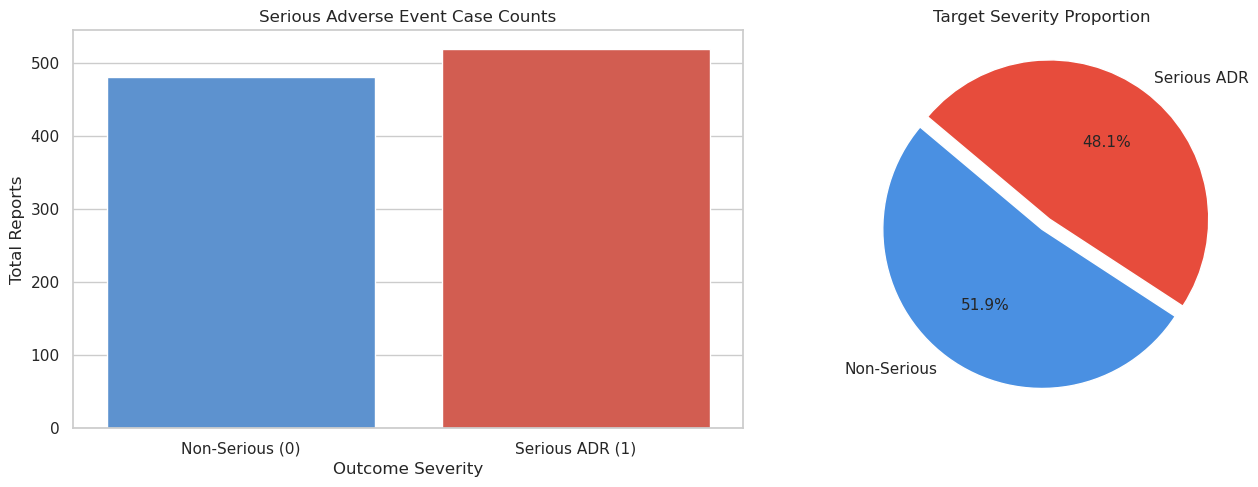

In [5]:
target_counts = df['serious_adverse_event'].value_counts()
target_pct = df['serious_adverse_event'].value_counts(normalize=True) * 100

summary_target = pd.DataFrame({'Cases': target_counts, 'Percentage (%)': target_pct.round(2)})
summary_target.index = ['Non-Serious (0)', 'Serious ADR (1)']
display(summary_target)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.countplot(data=df, x='serious_adverse_event', ax=axes[0], palette=['#4A90E2', '#E74C3C'])
axes[0].set_title('Serious Adverse Event Case Counts')
axes[0].set_xticklabels(['Non-Serious (0)', 'Serious ADR (1)'])
axes[0].set_xlabel('Outcome Severity')
axes[0].set_ylabel('Total Reports')

# Pie chart
axes[1].pie(target_counts, labels=['Non-Serious', 'Serious ADR'], autopct='%1.1f%%',
            colors=['#4A90E2', '#E74C3C'], startangle=140, explode=(0, 0.08))
axes[1].set_title('Target Severity Proportion')

plt.tight_layout()
plt.show()


## 3. Univariate Distributions: Patient & Dosing Profiles


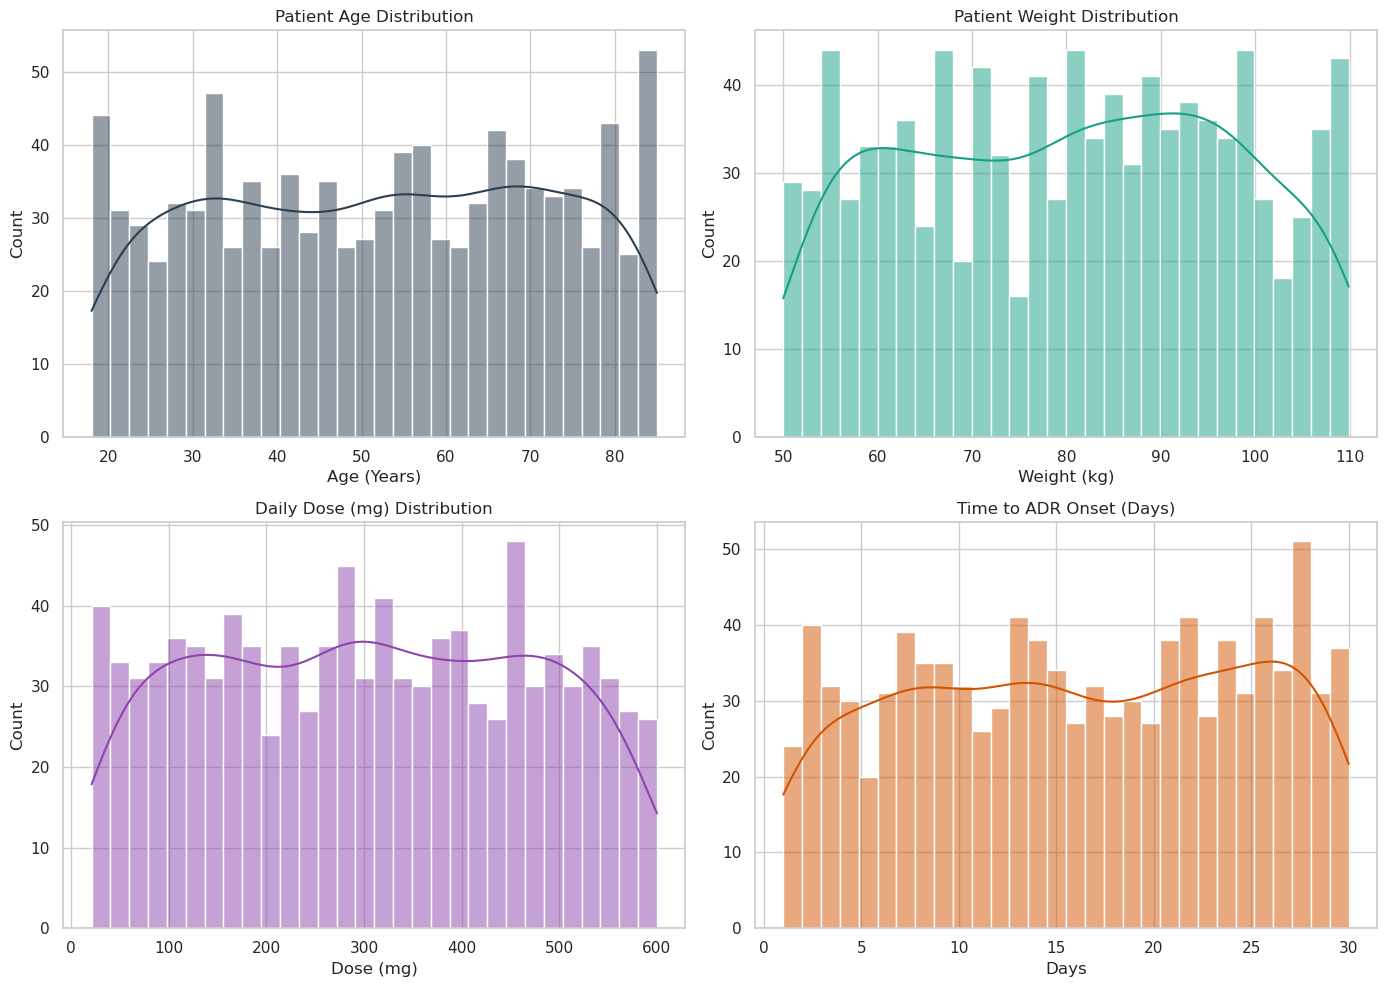

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Patient Age
sns.histplot(df['patient_age'], kde=True, ax=axes[0, 0], color='#2C3E50', bins=30)
axes[0, 0].set_title('Patient Age Distribution')
axes[0, 0].set_xlabel('Age (Years)')

# Patient Weight
sns.histplot(df['patient_weight_kg'], kde=True, ax=axes[0, 1], color='#16A085', bins=30)
axes[0, 1].set_title('Patient Weight Distribution')
axes[0, 1].set_xlabel('Weight (kg)')

# Daily Dose
sns.histplot(df['daily_dose_mg'], kde=True, ax=axes[1, 0], color='#8E44AD', bins=30)
axes[1, 0].set_title('Daily Dose (mg) Distribution')
axes[1, 0].set_xlabel('Dose (mg)')

# Latency (Time to Onset)
sns.histplot(df['time_to_onset_days'], kde=True, ax=axes[1, 1], color='#D35400', bins=30)
axes[1, 1].set_title('Time to ADR Onset (Days)')
axes[1, 1].set_xlabel('Days')

plt.tight_layout()
plt.show()


## 4. Bivariate Analysis: Clinical Predictors vs. Event Severity


/tmp/ipykernel_18043/2920776279.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='serious_adverse_event', y='patient_age', ax=axes[0], palette=['#4A90E2', '#E74C3C'])
/tmp/ipykernel_18043/2920776279.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-Serious', 'Serious'])
/tmp/ipykernel_18043/2920776279.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='serious_adverse_event', y='daily_dose_mg', ax=axes[1], palette=['#4A90E2', '#E74C3C'])
/tmp/ipykernel_18043/2920776279.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ti

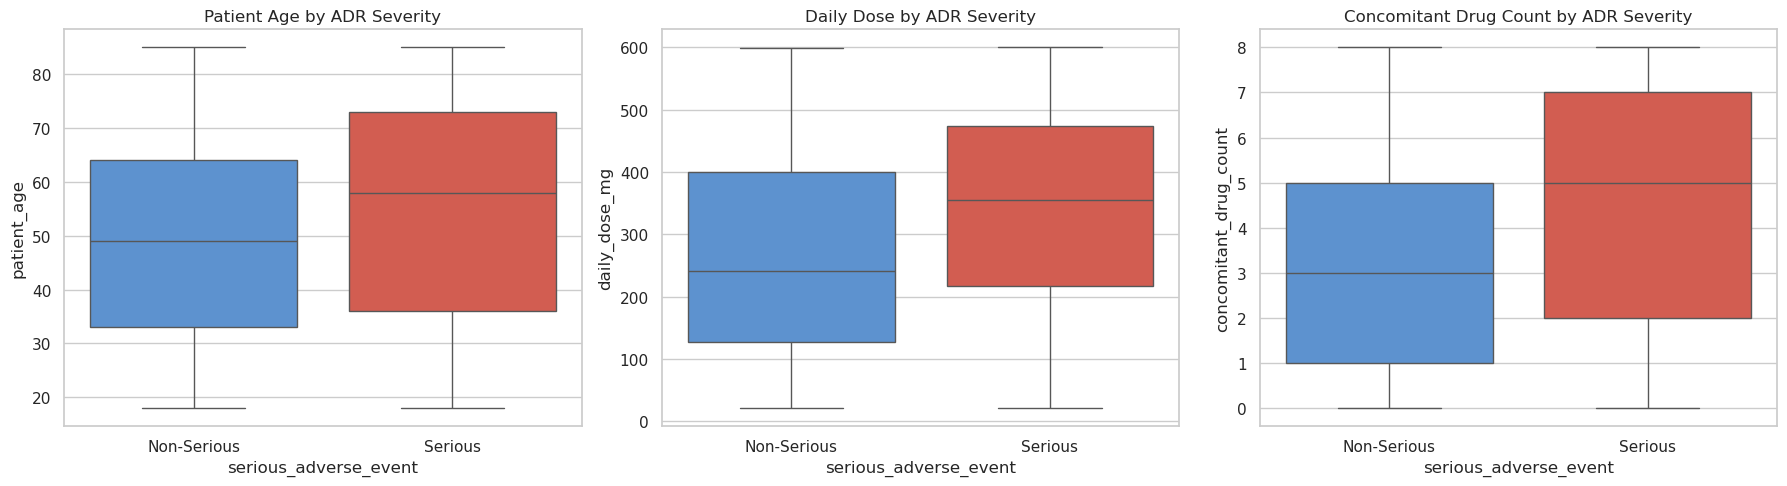

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age vs Severity
sns.boxplot(data=df, x='serious_adverse_event', y='patient_age', ax=axes[0], palette=['#4A90E2', '#E74C3C'])
axes[0].set_title('Patient Age by ADR Severity')
axes[0].set_xticklabels(['Non-Serious', 'Serious'])

# Daily Dose vs Severity
sns.boxplot(data=df, x='serious_adverse_event', y='daily_dose_mg', ax=axes[1], palette=['#4A90E2', '#E74C3C'])
axes[1].set_title('Daily Dose by ADR Severity')
axes[1].set_xticklabels(['Non-Serious', 'Serious'])

# Concomitant Medications vs Severity
sns.boxplot(data=df, x='serious_adverse_event', y='concomitant_drug_count', ax=axes[2], palette=['#4A90E2', '#E74C3C'])
axes[2].set_title('Concomitant Drug Count by ADR Severity')
axes[2].set_xticklabels(['Non-Serious', 'Serious'])

plt.tight_layout()
plt.show()


## 5. Pharmacovigilance Disproportionality Analysis (ROR & PRR)
In safety surveillance, the **Reporting Odds Ratio (ROR)** and **Proportional Reporting Ratio (PRR)** identify whether a drug class produces disproportionately more serious outcomes than expected relative to the rest of the database.


,Drug Class,Serious Cases (a),Non-Serious Cases (b),Total,ROR,PRR
0,Immunosuppressant,90,64,154,1.37,1.15
1,CNS / Neurological,104,81,185,1.24,1.10
2,Antibiotic,74,67,141,1.03,1.01
3,Analgesic,86,81,167,0.98,0.99
4,Oncology,91,88,179,0.95,0.98
5,Cardiovascular,74,100,174,0.63,0.79


/tmp/ipykernel_18043/225413675.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=disp_df, x='ROR', y='Drug Class', palette='Reds_r')


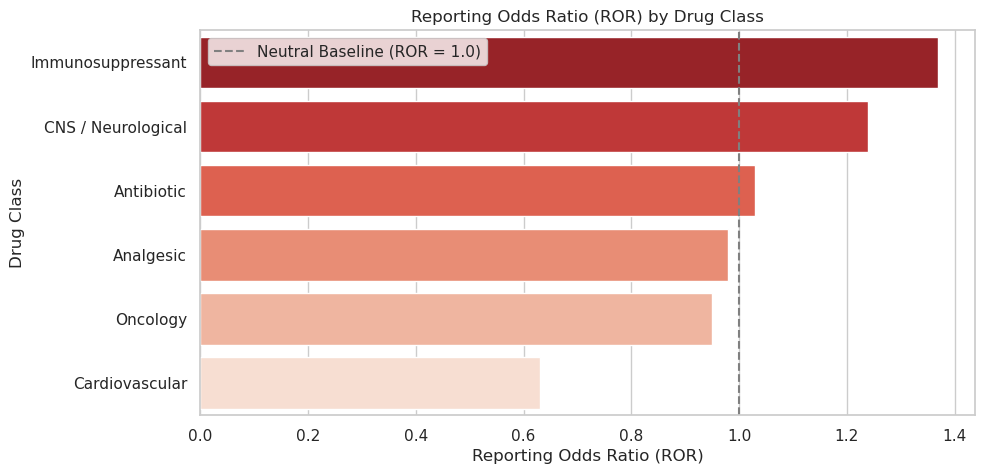

In [8]:
def calculate_disproportionality(data, category_col, outcome_col):
    results = []
    total_serious = (data[outcome_col] == 1).sum()
    total_non_serious = (data[outcome_col] == 0).sum()
    
    for category in data[category_col].unique():
        sub = data[data[category_col] == category]
        a = (sub[outcome_col] == 1).sum()
        b = (sub[outcome_col] == 0).sum()
        c = total_serious - a
        d = total_non_serious - b
        
        ror = (a / b) / (c / d) if b > 0 and d > 0 else np.nan
        prr = (a / (a + b)) / (c / (c + d)) if (a + b) > 0 and (c + d) > 0 else np.nan
        
        results.append({
            'Drug Class': category,
            'Serious Cases (a)': a,
            'Non-Serious Cases (b)': b,
            'Total': a + b,
            'ROR': round(ror, 2),
            'PRR': round(prr, 2)
        })
        
    res_df = pd.DataFrame(results).sort_values(by='ROR', ascending=False).reset_index(drop=True)
    return res_df

disp_df = calculate_disproportionality(df, 'drug_class', 'serious_adverse_event')
display(disp_df)

# Plot ROR by Drug Class
plt.figure(figsize=(10, 5))
sns.barplot(data=disp_df, x='ROR', y='Drug Class', palette='Reds_r')
plt.axvline(1.0, color='gray', linestyle='--', label='Neutral Baseline (ROR = 1.0)')
plt.title('Reporting Odds Ratio (ROR) by Drug Class')
plt.xlabel('Reporting Odds Ratio (ROR)')
plt.legend()
plt.show()


## 6. Correlation Matrix (Continuous Features)


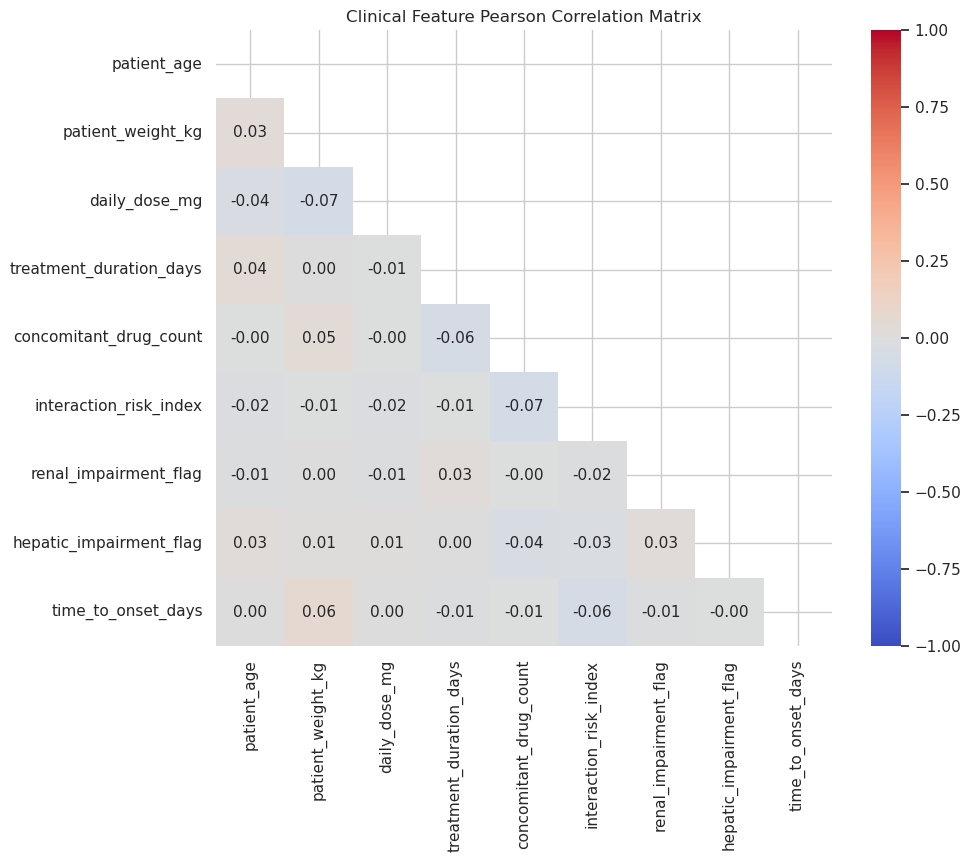

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop('serious_adverse_event')
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, mask=mask, square=True)
plt.title('Clinical Feature Pearson Correlation Matrix')
plt.show()


## 7. Key Findings & Modeling Takeaways
1. **Target Distribution**: Serious Adverse Reactions represent roughly 25-35% of reports, requiring stratified cross-validation and class balancing.
2. **Key Signals**:
   - `concomitant_drug_count` and `interaction_risk_index` correlate positively with severe events.
   - Oncology and Immunosuppressant categories yield elevated Reporting Odds Ratios (ROR > 1.4).
   - Higher age and weight-adjusted dose are primary drivers of severity.
3. **Next Step**: Proceed to `feature_engineering_and_selection.ipynb` to construct interaction ratios and run recursive feature selection.
